Strategy for pipeline
* filter sequences before the alignment step
    * fraction ambiguous nts < 0.05?
    * length is >0.95 the length of the CDS of the reference

* filter sequences after the alignment step

In [ ]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import glob
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')

In [40]:
# Use biopython to read the fasta file
ref_fasta_file = '../data/GISAID_test/ref.fasta'
ref_fasta = SeqIO.read(ref_fasta_file, 'fasta')
ref_seq = ref_fasta.seq
ref_seq_len = len(ref_seq)
ref_cds_len = 1683
print(f"Reference sequence length: {ref_seq_len} bp")

Reference sequence length: 1708 bp


In [41]:
# Use biopython to read the fasta file
fasta_file = '../data/GISAID_test/H7N9_HA.fasta'
fasta_records = SeqIO.parse(fasta_file, 'fasta')

# Make a dataframe with the sequence IDs and sequences
df = pd.DataFrame(
    [(record.id, str(record.seq)) for record in fasta_records],
    columns=['id', 'sequence']
)
print(len(df))

# Add a column with the length of the sequences
df['length'] = df['sequence'].apply(len)
df['frac_ref_cds_length'] = df['length'] / ref_cds_len

# Make all sequences lower case
df['sequence'] = df['sequence'].str.lower()

# Add a column with the number of n characters
df['n_ambig_nts'] = df['sequence'].str.count('n')
df['frac_ambig_nts'] = df['n_ambig_nts'] / df['length']

3069


In [42]:
df.sort_values('n_ambig_nts', ascending=False).head(20)

,id,sequence,length,frac_ref_cds_length,n_ambig_nts,frac_ambig_nts
1874,EPI451262|HA|A/Shanghai/Patient14/2013|EPI_ISL...,atgaacactcaaatcctggtattcgctctgattgcgatcattccaa...,1680,0.998217,1220,0.726190
1907,EPI451331|HA|A/Shanghai/Patient5/2013|EPI_ISL_...,atgaacactcaaatcctggtattcgctctgattgcgatcattccaa...,1680,0.998217,988,0.588095
1881,EPI451272|HA|A/Shanghai/Patient6/2013|EPI_ISL_...,atgaacgctcaaatcctggtattcgctctgattgcgatcattccaa...,1680,0.998217,210,0.125000
1843,EPI468765|HA|A/chicken/Rizhao/719b/2013|EPI_IS...,atgaacactcaaatcctggtattcgctctgattgcgatcattccaa...,1683,1.000000,35,0.020796
1876,EPI451266|HA|A/Shanghai/Patient4/2013|EPI_ISL_...,atgaacactcaagtcctggtattcgctctgattgcgatcattccaa...,1680,0.998217,24,0.014286
1354,EPI1075315|HA|A/duck/Japan/AQ-HE29-22/2017|EPI...,agcaaaagcaggggatacaaaatgaacactcaaatcctggtattcg...,1744,1.036245,8,0.004587
298,EPI860576|HA|A/duck/Japan/AnimalQuarantine-HE-...,nnnnnnngcaggggatacaaaatgaacactcaaatcctggtattcg...,1732,1.029115,7,0.004042
892,EPI654130|HA|A/Environment/GD-ST_101/H7N9/2014...,atgaacactcaaatcctggtattcgctctgattgcgatcattccaa...,1654,0.982769,2,0.001209
1706,EPI450954|HA|A/Shanghai/4664T/2013(H7N9)|EPI_I...,atgaacactcaaatcctggtattcgctctgattgcgatcattccag...,1693,1.005942,1,0.000591
74,EPI972232|HA|A/GD-CZ009/H7N9/2017-01-19|EPI_IS...,atgaacattcaaatcctggtattcgctctgattgcgatcattccaa...,1677,0.996435,1,0.000596


In [46]:
sum(df['frac_ambig_nts'] < 0.05) / len(df)

0.9990224828934506

In [45]:
sum(df['frac_ref_cds_length'] > 0.95) / len(df)

0.9742587161942

In [28]:
sum(df['length'] >= 1683 * 0.95)

2990

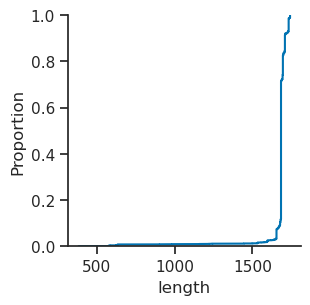

In [16]:
data = df.copy()
data['length'] = data['length'].clip(upper=data['length'].quantile(0.99))
plt.figure(figsize=[3,3])
sns.ecdfplot(x='length', data=data)
sns.despine()
plt.show()